# Process bulk counts table

1. Annotate columns (samples) in a way that time point and replicate are annotated
2. Remove rRNA genes
3. Perform TPM normalization and alternatively also raw counts

In [1]:
# Use miniconda environment Jupyter_new for running this notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from tools import *
import warnings
warnings.filterwarnings('ignore')

## 1 Load the dataset and annotation

In [2]:
bulkPath = '../nf_output/countData/countData.tsv' 
metaPath = '../SraRunTable.csv' # metadata from SRA
gffPath = '../nf_output/alignments/dualGenome.gff3' # output from nf pipeline

In [3]:
# Load data
df_initial = pd.read_csv(bulkPath, sep = '\t', comment='#', index_col=0)
metadata = pd.read_csv(metaPath)

In [4]:
df_initial

,Chr,Start,End,Strand,Length,SRR38081879_sorted.bam,SRR38081882_sorted.bam,SRR38081881_sorted.bam,SRR38081880_sorted.bam,SRR38081883_sorted.bam,SRR38081884_sorted.bam
Geneid,,,,,,,,,,,
gene-HB27c_C0001,CP053287.1,74,1171,-,1098,2,4,10,21,21,66
gene-HB27c_C0002,CP053287.1,1281,2051,+,771,24,44,113,172,114,217
gene-HB27c_C0003,CP053287.1,2097,2639,-,543,100,188,360,630,621,1035
gene-HB27c_C0004,CP053287.1,3280,3362,-,83,4,4,15,5,9,10
gene-HB27c_C0005,CP053287.1,3982,4311,+,330,1,5,12,21,24,45
...,...,...,...,...,...,...,...,...,...,...,...
gene-Lalka27a_80,PQ109076.1,67586,68011,-,426,41,112,250,638,331,466
gene-Lalka27a_81,PQ109076.1,68033,68437,-,405,27,94,218,480,259,321
gene-Lalka27a_82,PQ109076.1,68552,69232,+,681,34,106,72,507,76,101


In [5]:
metadata

,Run,Assay Type,AvgSpotLen,Bases,BioProject,BioSample,BioSampleModel,Bytes,Center Name,Collection_Date,...,LibrarySource,Organism,Platform,ReleaseDate,create_date,version,Sample Name,sample_type,SRA Study,strain
0,SRR38081879,RNA-Seq,300,980883300,PRJNA1452983,SAMN57247762,"Microbe\, viral or environmental",737576377,INSTITUTE OF GENE BIOLOGY RUSSIAN ACADEMY OF S...,2025-10-07,...,TRANSCRIPTOMIC,Thermus thermophilus,DNBSEQ,2026-04-20T00:00:00Z,2026-04-13T16:45:00Z,1,High-throughput RNA-Seq data of Thermus thermo...,cell culture,SRP691566,HB27c
1,SRR38081880,RNA-Seq,300,4645852200,PRJNA1452983,SAMN57247762,"Microbe\, viral or environmental",3533083841,INSTITUTE OF GENE BIOLOGY RUSSIAN ACADEMY OF S...,2025-10-07,...,TRANSCRIPTOMIC,Thermus thermophilus,DNBSEQ,2026-04-20T00:00:00Z,2026-04-13T16:52:00Z,1,High-throughput RNA-Seq data of Thermus thermo...,cell culture,SRP691566,HB27c
2,SRR38081881,RNA-Seq,300,3322167600,PRJNA1452983,SAMN57247762,"Microbe\, viral or environmental",2494252047,INSTITUTE OF GENE BIOLOGY RUSSIAN ACADEMY OF S...,2025-10-07,...,TRANSCRIPTOMIC,Thermus thermophilus,DNBSEQ,2026-04-20T00:00:00Z,2026-04-13T16:49:00Z,1,High-throughput RNA-Seq data of Thermus thermo...,cell culture,SRP691566,HB27c
3,SRR38081882,RNA-Seq,300,1696796700,PRJNA1452983,SAMN57247762,"Microbe\, viral or environmental",1283311344,INSTITUTE OF GENE BIOLOGY RUSSIAN ACADEMY OF S...,2025-10-07,...,TRANSCRIPTOMIC,Thermus thermophilus,DNBSEQ,2026-04-20T00:00:00Z,2026-04-13T16:46:00Z,1,High-throughput RNA-Seq data of Thermus thermo...,cell culture,SRP691566,HB27c
4,SRR38081883,RNA-Seq,300,4426210500,PRJNA1452983,SAMN57247762,"Microbe\, viral or environmental",3317845099,INSTITUTE OF GENE BIOLOGY RUSSIAN ACADEMY OF S...,2025-10-07,...,TRANSCRIPTOMIC,Thermus thermophilus,DNBSEQ,2026-04-20T00:00:00Z,2026-04-13T16:53:00Z,1,High-throughput RNA-Seq data of Thermus thermo...,cell culture,SRP691566,HB27c
5,SRR38081884,RNA-Seq,300,8222307300,PRJNA1452983,SAMN57247762,"Microbe\, viral or environmental",6245465473,INSTITUTE OF GENE BIOLOGY RUSSIAN ACADEMY OF S...,2025-10-07,...,TRANSCRIPTOMIC,Thermus thermophilus,DNBSEQ,2026-04-20T00:00:00Z,2026-04-13T17:03:00Z,1,High-throughput RNA-Seq data of Thermus thermo...,cell culture,SRP691566,HB27c
6,SRR38081890,RNA-Seq,300,2714053500,PRJNA1452983,SAMN57247762,"Microbe\, viral or environmental",1924464356,INSTITUTE OF GENE BIOLOGY RUSSIAN ACADEMY OF S...,2025-10-07,...,TRANSCRIPTOMIC,Thermus thermophilus,DNBSEQ,2026-04-20T00:00:00Z,2026-04-13T16:46:00Z,1,High-throughput RNA-Seq data of Thermus thermo...,cell culture,SRP691566,HB27c
7,SRR38081891,RNA-Seq,300,2517682800,PRJNA1452983,SAMN57247762,"Microbe\, viral or environmental",1783789749,INSTITUTE OF GENE BIOLOGY RUSSIAN ACADEMY OF S...,2025-10-07,...,TRANSCRIPTOMIC,Thermus thermophilus,DNBSEQ,2026-04-20T00:00:00Z,2026-04-13T16:46:00Z,1,High-throughput RNA-Seq data of Thermus thermo...,cell culture,SRP691566,HB27c
8,SRR38081892,RNA-Seq,300,2052622800,PRJNA1452983,SAMN57247762,"Microbe\, viral or environmental",1475838988,INSTITUTE OF GENE BIOLOGY RUSSIAN ACADEMY OF S...,2025-10-07,...,TRANSCRIPTOMIC,Thermus thermophilus,DNBSEQ,2026-04-20T00:00:00Z,2026-04-13T16:46:00Z,1,High-throughput RNA-Seq data of Thermus thermo...,cell culture,SRP691566,HB27c
9,SRR38115016,RNA-Seq,300,95324700,PRJNA1452983,SAMN57286651,"Microbe\, viral or environmental",77173438,INSTITUTE OF GENE BIOLOGY RUSSIAN ACADEMY OF S...,2025-10-07,...,TRANSCRIPTOMIC,Thermus thermophilus,DNBSEQ,2026-04-20T00:00:00Z,2026-04-15T11:09:00Z,1,Thermus thermophilus HB27c cells expressing la...,cell culture,SRP691566,HB27c


In [6]:
metadata = metadata.loc[metadata['Assay Type'] == 'RNA-Seq']
metadata

,Run,Assay Type,AvgSpotLen,Bases,BioProject,BioSample,BioSampleModel,Bytes,Center Name,Collection_Date,...,LibrarySource,Organism,Platform,ReleaseDate,create_date,version,Sample Name,sample_type,SRA Study,strain
0,SRR38081879,RNA-Seq,300,980883300,PRJNA1452983,SAMN57247762,"Microbe\, viral or environmental",737576377,INSTITUTE OF GENE BIOLOGY RUSSIAN ACADEMY OF S...,2025-10-07,...,TRANSCRIPTOMIC,Thermus thermophilus,DNBSEQ,2026-04-20T00:00:00Z,2026-04-13T16:45:00Z,1,High-throughput RNA-Seq data of Thermus thermo...,cell culture,SRP691566,HB27c
1,SRR38081880,RNA-Seq,300,4645852200,PRJNA1452983,SAMN57247762,"Microbe\, viral or environmental",3533083841,INSTITUTE OF GENE BIOLOGY RUSSIAN ACADEMY OF S...,2025-10-07,...,TRANSCRIPTOMIC,Thermus thermophilus,DNBSEQ,2026-04-20T00:00:00Z,2026-04-13T16:52:00Z,1,High-throughput RNA-Seq data of Thermus thermo...,cell culture,SRP691566,HB27c
2,SRR38081881,RNA-Seq,300,3322167600,PRJNA1452983,SAMN57247762,"Microbe\, viral or environmental",2494252047,INSTITUTE OF GENE BIOLOGY RUSSIAN ACADEMY OF S...,2025-10-07,...,TRANSCRIPTOMIC,Thermus thermophilus,DNBSEQ,2026-04-20T00:00:00Z,2026-04-13T16:49:00Z,1,High-throughput RNA-Seq data of Thermus thermo...,cell culture,SRP691566,HB27c
3,SRR38081882,RNA-Seq,300,1696796700,PRJNA1452983,SAMN57247762,"Microbe\, viral or environmental",1283311344,INSTITUTE OF GENE BIOLOGY RUSSIAN ACADEMY OF S...,2025-10-07,...,TRANSCRIPTOMIC,Thermus thermophilus,DNBSEQ,2026-04-20T00:00:00Z,2026-04-13T16:46:00Z,1,High-throughput RNA-Seq data of Thermus thermo...,cell culture,SRP691566,HB27c
4,SRR38081883,RNA-Seq,300,4426210500,PRJNA1452983,SAMN57247762,"Microbe\, viral or environmental",3317845099,INSTITUTE OF GENE BIOLOGY RUSSIAN ACADEMY OF S...,2025-10-07,...,TRANSCRIPTOMIC,Thermus thermophilus,DNBSEQ,2026-04-20T00:00:00Z,2026-04-13T16:53:00Z,1,High-throughput RNA-Seq data of Thermus thermo...,cell culture,SRP691566,HB27c
5,SRR38081884,RNA-Seq,300,8222307300,PRJNA1452983,SAMN57247762,"Microbe\, viral or environmental",6245465473,INSTITUTE OF GENE BIOLOGY RUSSIAN ACADEMY OF S...,2025-10-07,...,TRANSCRIPTOMIC,Thermus thermophilus,DNBSEQ,2026-04-20T00:00:00Z,2026-04-13T17:03:00Z,1,High-throughput RNA-Seq data of Thermus thermo...,cell culture,SRP691566,HB27c
6,SRR38081890,RNA-Seq,300,2714053500,PRJNA1452983,SAMN57247762,"Microbe\, viral or environmental",1924464356,INSTITUTE OF GENE BIOLOGY RUSSIAN ACADEMY OF S...,2025-10-07,...,TRANSCRIPTOMIC,Thermus thermophilus,DNBSEQ,2026-04-20T00:00:00Z,2026-04-13T16:46:00Z,1,High-throughput RNA-Seq data of Thermus thermo...,cell culture,SRP691566,HB27c
7,SRR38081891,RNA-Seq,300,2517682800,PRJNA1452983,SAMN57247762,"Microbe\, viral or environmental",1783789749,INSTITUTE OF GENE BIOLOGY RUSSIAN ACADEMY OF S...,2025-10-07,...,TRANSCRIPTOMIC,Thermus thermophilus,DNBSEQ,2026-04-20T00:00:00Z,2026-04-13T16:46:00Z,1,High-throughput RNA-Seq data of Thermus thermo...,cell culture,SRP691566,HB27c
8,SRR38081892,RNA-Seq,300,2052622800,PRJNA1452983,SAMN57247762,"Microbe\, viral or environmental",1475838988,INSTITUTE OF GENE BIOLOGY RUSSIAN ACADEMY OF S...,2025-10-07,...,TRANSCRIPTOMIC,Thermus thermophilus,DNBSEQ,2026-04-20T00:00:00Z,2026-04-13T16:46:00Z,1,High-throughput RNA-Seq data of Thermus thermo...,cell culture,SRP691566,HB27c
9,SRR38115016,RNA-Seq,300,95324700,PRJNA1452983,SAMN57286651,"Microbe\, viral or environmental",77173438,INSTITUTE OF GENE BIOLOGY RUSSIAN ACADEMY OF S...,2025-10-07,...,TRANSCRIPTOMIC,Thermus thermophilus,DNBSEQ,2026-04-20T00:00:00Z,2026-04-15T11:09:00Z,1,Thermus thermophilus HB27c cells expressing la...,cell culture,SRP691566,HB27c


In [7]:
metadata['Library Name'] # required column for sample name annotation

0                       T65_min
1                       T40_min
2                       T20_min
3                       T50_min
4                       T10_min
5                        T5_min
6                      T40_sRNA
7                      T20_sRNA
8                       T5_sRNA
9            cas12_phiKo_18nt_2
10           cas12_phiKo_18nt_1
11    cas12_r_phiko_r_phiFa_r_2
12    cas12_r_phiko_r_phiFa_r_1
13    cas12_r_phiko_r_phiFa_r_2
14    cas12_r_phiko_r_phiFa_r_1
Name: Library Name, dtype: object

## 2 Format the dataset

### 2.1 Annotate sample names

Issue now is that the metadata does not properly annotate sample names. Thus, this will be done manually by adding another sample name column to the metadata.

In [8]:
# Match SRR IDs and SampleNames inferred from metadata

sampleInfo = metadata[['Run', 'Library Name']]
sampleInfo['timepoint'] = sampleInfo['Library Name'].str.split('_', expand=True)[0]
sampleInfo['sampleName'] = sampleInfo['timepoint'].str.split('T', expand=True)[1]
sampleInfo.index = sampleInfo['Run']
sampleInfo

,Run,Library Name,timepoint,sampleName
Run,,,,
SRR38081879,SRR38081879,T65_min,T65,65
SRR38081880,SRR38081880,T40_min,T40,40
SRR38081881,SRR38081881,T20_min,T20,20
SRR38081882,SRR38081882,T50_min,T50,50
SRR38081883,SRR38081883,T10_min,T10,10
SRR38081884,SRR38081884,T5_min,T5,5
SRR38081890,SRR38081890,T40_sRNA,T40,40
SRR38081891,SRR38081891,T20_sRNA,T20,20
SRR38081892,SRR38081892,T5_sRNA,T5,5


In [9]:
sampleDict = sampleInfo['sampleName'].to_dict()
sampleDict

{'SRR38081879': '65',
 'SRR38081880': '40',
 'SRR38081881': '20',
 'SRR38081882': '50',
 'SRR38081883': '10',
 'SRR38081884': '5',
 'SRR38081890': '40',
 'SRR38081891': '20',
 'SRR38081892': '5',
 'SRR38115016': None,
 'SRR38115017': None,
 'SRR38102645': None,
 'SRR38102646': None,
 'SRR38102979': None,
 'SRR38102980': None}

In [10]:
metadataFull = annotateData(metadata, sampleDict)

In [11]:
metadataFull.head(1)

,Run,Assay Type,AvgSpotLen,Bases,BioProject,BioSample,BioSampleModel,Bytes,Center Name,Collection_Date,...,Platform,ReleaseDate,create_date,version,Sample Name,sample_type,SRA Study,strain,SampleID,SampleNames
SampleID,,,,,,,,,,,,,,,,,,,,,
SRR38081879_sorted.bam,SRR38081879,RNA-Seq,300,980883300,PRJNA1452983,SAMN57247762,"Microbe\, viral or environmental",737576377,INSTITUTE OF GENE BIOLOGY RUSSIAN ACADEMY OF S...,2025-10-07,...,DNBSEQ,2026-04-20T00:00:00Z,2026-04-13T16:45:00Z,1,High-throughput RNA-Seq data of Thermus thermo...,cell culture,SRP691566,HB27c,SRR38081879_sorted.bam,65


Add correct sample names.

In [12]:
df = changeColnames(df_initial.iloc[:,5:df_initial.shape[1]], metadataFull)
df = df[['5', '10', '20', '40', '50', '65']]
df

SampleNames,5,10,20,40,50,65
Geneid,,,,,,
gene-HB27c_C0001,66,21,10,21,4,2
gene-HB27c_C0002,217,114,113,172,44,24
gene-HB27c_C0003,1035,621,360,630,188,100
gene-HB27c_C0004,10,9,15,5,4,4
gene-HB27c_C0005,45,24,12,21,5,1
...,...,...,...,...,...,...
gene-Lalka27a_80,466,331,250,638,112,41
gene-Lalka27a_81,321,259,218,480,94,27
gene-Lalka27a_82,101,76,72,507,106,34


### 2.2 Remove rRNA genes

2.1 Process gff3 files for front end processing

In [13]:
# Load gff3 and split into genes and CDS dfs
gff3 = pd.read_csv(gffPath, sep='\t', header = None, comment='#')
gff3.columns=["seq_id", "source", "type", "start", "end", "phase", "strand", "score", "attributes"]
gff3_genes = gff3.loc[gff3["type"] == 'gene']

# Column formating for genes
gff3_genes = gff3_genes.reset_index(drop=True)
dct_genes = gff3_genes["attributes"].str.split(';').apply(lambda items: dict(item.split('=', 1) for item in items if '=' in item))
cols_to_keep = ['ID', 'Name', 'gbkey', 'gene_biotype', 'locus_tag', 'gene']
gff3_genes = pd.concat([gff3_genes, pd.json_normalize(dct_genes)[cols_to_keep]], axis=1)

# Generate locus_tag, product dictonary over all different feature types
attrs = gff3["attributes"].str.split(";", expand=True)
attrs_dicts = attrs.apply(lambda row: {item.split("=")[0]: item.split("=")[1] for item in row if "=" in str(item)}, axis=1)
attrs_df = pd.json_normalize(attrs_dicts)
attrs_df = attrs_df.dropna(subset=["locus_tag", "product"])
locus_product_dict = dict(zip(attrs_df["locus_tag"], attrs_df["product"]))

# Add gene product, if not stated in gff3, fill with gene_biotype
gff3_genes["product"] = gff3_genes["locus_tag"].map(locus_product_dict)
gff3_genes["product"] = gff3_genes["product"].fillna("other")
# gff3_genes["product"] = gff3_genes["product"].fillna(gff3_genes["gene_biotype"])

# If gene = NA, take from ID column
gff3_genes["gene"] = gff3_genes["gene"].fillna(gff3_genes["ID"])

# Drop attributes column
gff3_genes = gff3_genes.drop(["attributes"], axis=1)

In [14]:
pharokka_path = "../../../2025-12_reannotation_phage_genomes/Pharokka_proteins_phages_out/PQ109076.1_out/pharokka_proteins_full_merged_output.tsv"
gff3_genes = add_pharokka(gff3_genes, pharokka_path)
gff3_genes.loc[gff3_genes['seq_id'] == "PQ109076.1"]

,seq_id,source,type,start,end,phase,strand,score,ID,Name,gbkey,gene_biotype,locus_tag,gene,product,annot,PHROG,category
2322,PQ109076.1,Genbank,gene,27,404,.,-,.,gene-Lalka27a_1,Lalka27a_1,Gene,protein_coding,Lalka27a_1,gene-Lalka27a_1,Ulx-like anti-restriction protein,Ulx-like anti-restriction,1629,"moron, auxiliary metabolic gene and host takeover"
2323,PQ109076.1,Genbank,gene,397,6621,.,-,.,gene-Lalka27a_2,Lalka27a_2,Gene,protein_coding,Lalka27a_2,gene-Lalka27a_2,DarB-like anti-restriction protein,DNA methyltransferase,11801,other
2324,PQ109076.1,Genbank,gene,6747,7469,.,+,.,gene-Lalka27a_3,Lalka27a_3,Gene,protein_coding,Lalka27a_3,gene-Lalka27a_3,ssDNA binding protein,single strand DNA binding protein,44,"DNA, RNA and nucleotide metabolism"
2325,PQ109076.1,Genbank,gene,7659,8942,.,-,.,gene-Lalka27a_4,Lalka27a_4,Gene,protein_coding,Lalka27a_4,gene-Lalka27a_4,hypothetical protein,hypothetical protein,No_PHROG,unknown function
2326,PQ109076.1,Genbank,gene,9045,9293,.,+,.,gene-Lalka27a_5,Lalka27a_5,Gene,protein_coding,Lalka27a_5,gene-Lalka27a_5,hypothetical protein,hypothetical protein,No_PHROG,unknown function
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2401,PQ109076.1,Genbank,gene,67586,68011,.,-,.,gene-Lalka27a_80,Lalka27a_80,Gene,protein_coding,Lalka27a_80,gene-Lalka27a_80,hypothetical protein,hypothetical protein,No_PHROG,unknown function
2402,PQ109076.1,Genbank,gene,68033,68437,.,-,.,gene-Lalka27a_81,Lalka27a_81,Gene,protein_coding,Lalka27a_81,gene-Lalka27a_81,transcriptional regulator,transcriptional repressor,3,transcription regulation
2403,PQ109076.1,Genbank,gene,68552,69232,.,+,.,gene-Lalka27a_82,Lalka27a_82,Gene,protein_coding,Lalka27a_82,gene-Lalka27a_82,LexA-like regulator,transcriptional repressor,4,transcription regulation
2404,PQ109076.1,Genbank,gene,69234,69887,.,+,.,gene-Lalka27a_83,Lalka27a_83,Gene,protein_coding,Lalka27a_83,gene-Lalka27a_83,hypothetical protein,hypothetical protein,No_PHROG,unknown function


2.2 Consult gff3 file to get rRNA geneids.

In [15]:
# Load ggf3 file

gff3 = pd.read_csv(gffPath, sep='\t', header = None, comment='#')
gff3 = gff3.loc[gff3.iloc[:,2] == 'gene']

# Format some new columns
gff3['ID'] = pd.DataFrame(gff3.iloc[:,8].str.split('ID=', expand = True)).iloc[:,1].str.split(';', expand = True).iloc[:,0]
gff3['GeneType'] = pd.DataFrame(gff3.iloc[:,8].str.split('gene_biotype=', expand = True)).iloc[:,1].str.split(';', expand = True).iloc[:,0]
gff3['Symbol'] = pd.DataFrame(gff3.iloc[:,8].str.split('gene=', expand = True)).iloc[:,1].str.split(';', expand = True).iloc[:,0]

# Add entity host and phage
entity = {'CP053287.1' : 'host',
 'CP053288.1' : 'host',
 'PQ109076.1' : 'phage'}
gff3['Entity'] = gff3[0].map(entity)
gff3.index = gff3['ID']
rRNAs = gff3.loc[gff3['GeneType'] == 'rRNA', 'ID'].tolist()

Perform in silico rRNA depletion.

In [16]:
df_norRNAs = rRNAdepletion(df,rRNAs)
df_norRNAs

SampleNames,5,10,20,40,50,65
Geneid,,,,,,
gene-HB27c_C0430,115,47,35,82,21,11
gene-HB27c_C0471,38,34,19,35,11,9
gene-HB27c_C1367,72169,23199,18336,28744,6699,5022
gene-HB27c_C0053,666,344,229,382,93,83
gene-HB27c_C1408,44,41,22,55,17,6
...,...,...,...,...,...,...
gene-HB27c_C0695,3967,2200,1481,3123,1142,951
gene-HB27c_C1806,2417,974,1187,1008,271,215
gene-HB27c_C0296,1424,528,427,759,179,138


### 2.3 Read count normalization

Important note: gene symbols not available for most genes.

In [17]:
# Function to fill in missing symbols by geneid.

def fillSymbols(df):
    df_new = df.copy()
    index = df.index.to_list()
    for i in range(0,df.shape[0]):
        if (df.iloc[i,-1:].values == None):
            df_new.iloc[i,-1:] = index[i]
    return df_new

Convert counts to TPM.

In [18]:
tpms = TPM(df_norRNAs, df_initial, 0.5)
tpms['Entity'] = gff3.loc[sorted(tpms.index.to_list()), 'Entity']
tpms['Symbol'] = gff3.loc[sorted(tpms.index.to_list()), 'Symbol']

tpms = fillSymbols(tpms)
tpms = make_unique_with_index(tpms)
tpms

SampleNames,5,10,20,40,50,65,Entity,Symbol
Geneid,,,,,,,,
gene-HB27c_C0430,23.041256,19.159714,22.753491,26.999760,33.497851,34.061472,host,gene-HB27c_C0430
gene-HB27c_C0471,7.947564,14.400038,12.933123,12.022186,18.540671,29.116442,host,gene-HB27c_C0471
gene-HB27c_C1367,8418.998193,5472.132297,6872.562155,5501.020580,6103.844070,8698.974649,host,gene-HB27c_C1367
gene-HB27c_C0053,50.309574,52.578834,55.658140,47.365673,55.120914,93.578991,host,gene-HB27c_C0053
gene-HB27c_C1408,16.252411,30.646234,26.401938,33.253132,49.917192,35.246219,host,gene-HB27c_C1408
...,...,...,...,...,...,...,...,...
gene-HB27c_C0695,658.645959,738.631309,790.191339,850.664673,1481.308872,2345.229176,host,gene-HB27c_C0695
gene-HB27c_C1806,354.260394,288.741499,559.094540,242.445324,310.727916,468.861738,host,gene-HB27c_C1806
gene-HB27c_C0296,213.355735,160.050893,205.718571,186.617100,209.971639,307.987464,host,gene-HB27c_C0296


In [19]:
# Check gene names unique
len(tpms['Symbol'].unique())

2400

Log2+1 normalization raw counts

In [20]:
logs = logNorm(df_norRNAs)
logs['Entity'] = gff3.loc[sorted(logs.index.to_list()), 'Entity']
logs['Symbol'] = gff3.loc[sorted(logs.index.to_list()), 'Symbol']
logs = fillSymbols(logs)
# Make gene names unique
logs = make_unique_with_index(logs)
logs

SampleNames,5,10,20,40,50,65,Entity,Symbol
Geneid,,,,,,,,
gene-HB27c_C0430,6.857981,5.584963,5.169925,6.375039,4.459432,3.584963,host,gene-HB27c_C0430
gene-HB27c_C0471,5.285402,5.129283,4.321928,5.169925,3.584963,3.321928,host,gene-HB27c_C0471
gene-HB27c_C1367,16.139112,14.501837,14.162470,14.811023,12.709945,12.294334,host,gene-HB27c_C1367
gene-HB27c_C0053,9.381543,8.430453,7.845490,8.581201,6.554589,6.392317,host,gene-HB27c_C0053
gene-HB27c_C1408,5.491853,5.392317,4.523562,5.807355,4.169925,2.807355,host,gene-HB27c_C1408
...,...,...,...,...,...,...,...,...
gene-HB27c_C0695,11.954196,11.103943,10.533330,11.609179,10.158610,9.894818,host,gene-HB27c_C0695
gene-HB27c_C1806,11.239599,9.929258,10.214319,9.978710,8.087463,7.754888,host,gene-HB27c_C1806
gene-HB27c_C0296,10.476746,9.047124,8.741467,9.569856,7.491853,7.118941,host,gene-HB27c_C0296


Log2+1 normalization tpms

In [21]:
logTPMs = logNorm(tpms.iloc[:, :-2])
logTPMs = logTPMs.join(tpms.iloc[:, -2:])
logTPMs = fillSymbols(logTPMs)
# Make gene names unique
logTPMs = make_unique_with_index(logTPMs)
logTPMs

SampleNames,5,10,20,40,50,65,Entity,Symbol
Geneid,,,,,,,,
gene-HB27c_C0430,4.587440,4.333403,4.570068,4.807343,5.108435,5.131815,host,gene-HB27c_C0430
gene-HB27c_C0471,3.161495,3.944862,3.800447,3.702900,4.288408,4.912479,host,gene-HB27c_C0471
gene-HB27c_C1367,13.039604,12.418151,12.746842,12.425746,12.575739,13.086795,host,gene-HB27c_C1367
gene-HB27c_C0053,5.681156,5.743591,5.824211,5.595912,5.810467,6.563448,host,gene-HB27c_C0053
gene-HB27c_C1408,4.108726,4.983962,4.776206,5.098164,5.670081,5.179759,host,gene-HB27c_C1408
...,...,...,...,...,...,...,...,...
gene-HB27c_C0695,9.365548,9.530662,9.627883,9.734142,10.533630,11.196128,host,gene-HB27c_C0695
gene-HB27c_C1806,8.472733,8.178623,9.129527,7.927454,8.284144,8.876092,host,gene-HB27c_C1806
gene-HB27c_C0296,7.743863,7.331373,7.691524,7.551648,7.720905,8.271404,host,gene-HB27c_C0296


## 3 Filter samples, if necessary

Look for outliers visually by PCA.

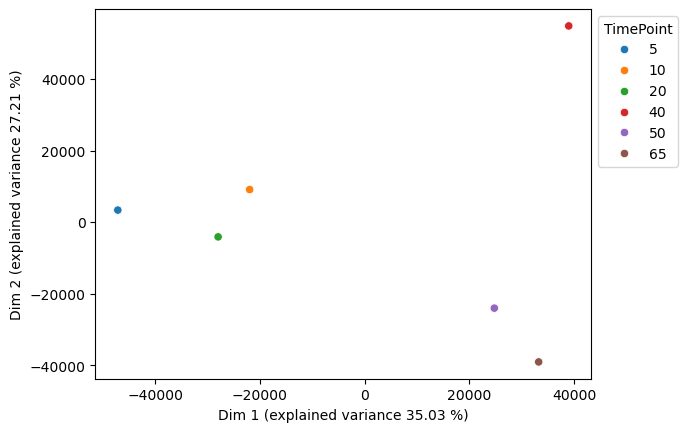

In [22]:
txPCA(tpms.iloc[:,0:tpms.shape[1]-2])

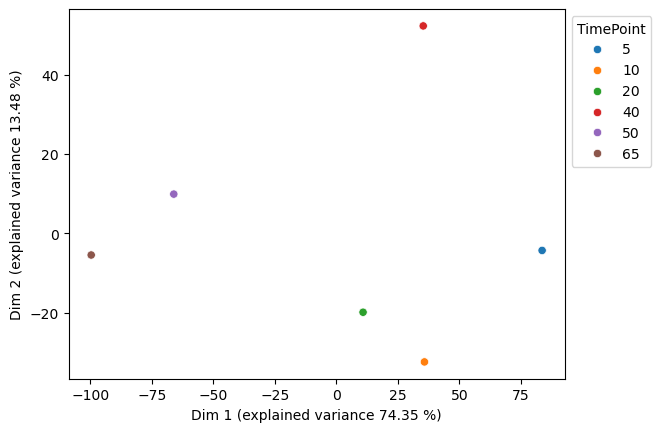

In [23]:
txPCA(logs.iloc[:,0:logs.shape[1]-2])

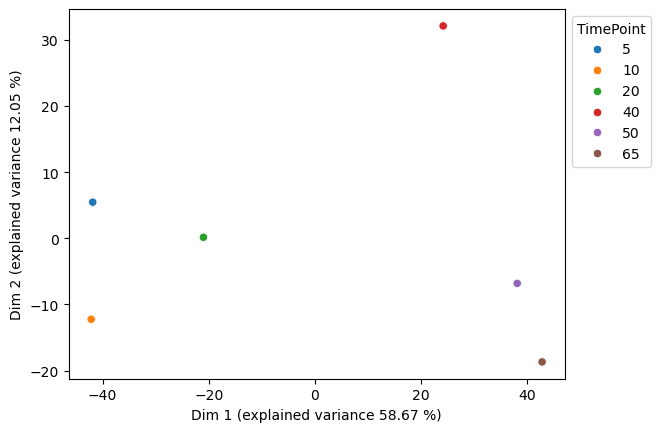

In [24]:
txPCA(logTPMs.iloc[:,0:logTPMs.shape[1]-2])

In [25]:
tpmHost = tpms[tpms['Entity'] == 'host']
tpmPhage = tpms[tpms['Entity'] == 'phage']
logTPMsHost = logTPMs[logTPMs['Entity'] == 'host']
logTPMsPhage = logTPMs[logTPMs['Entity'] == 'phage']

tpmHost

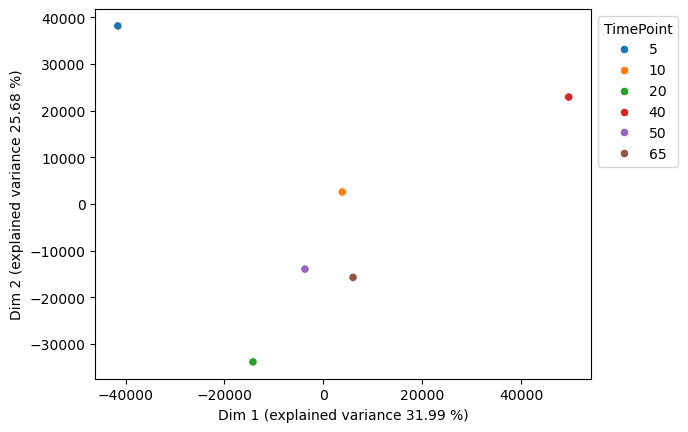

In [26]:
txPCA(tpmHost.iloc[:,0:tpmHost.shape[1]-2])

tpmPhage

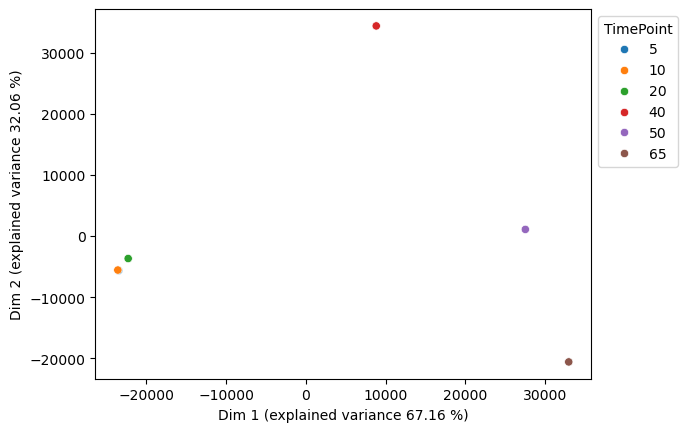

In [27]:
txPCA(tpmPhage.iloc[:,0:tpmPhage.shape[1]-2])

logTPM Host

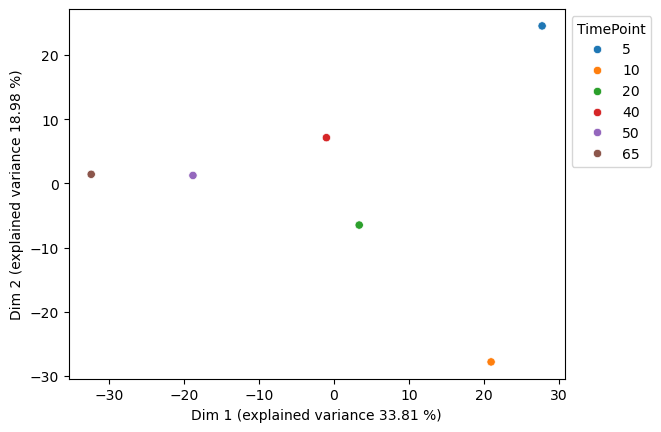

In [28]:
txPCA(logTPMsHost.iloc[:,0:logTPMsHost.shape[1]-2])

logTPM Phage

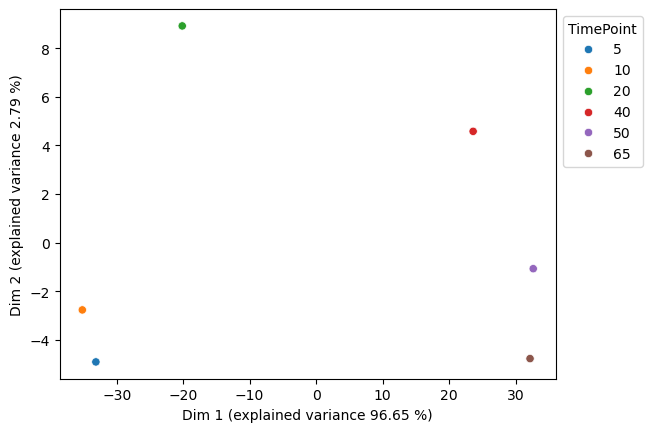

In [29]:
txPCA(logTPMsPhage.iloc[:,0:logTPMsPhage.shape[1]-2])

## 4. Final grouping

In [30]:
TPMmeans = tpms
TPMmeans
logTPM = logTPMs[['5', '10', '20', '40', '50', '65']]
logTPM[['Entity', 'Symbol']] = tpms[['Entity', 'Symbol']]
raw = df_norRNAs[['5', '10', '20', '40', '50', '65']]
raw[['Entity', 'Symbol']] = tpms[['Entity', 'Symbol']]

In [31]:
propExp = proportionalExp(TPMmeans[['5', '10', '20', '40', '50', '65']])
propExp[['Entity', 'Symbol']] = TPMmeans[['Entity', 'Symbol']]
propExp

SampleNames,5,10,20,40,50,65,Entity,Symbol
Geneid,,,,,,,,
gene-HB27c_C0430,0.676461,0.562504,0.668013,0.792677,0.983453,1.000000,host,gene-HB27c_C0430
gene-HB27c_C0471,0.272958,0.494567,0.444186,0.412900,0.636777,1.000000,host,gene-HB27c_C0471
gene-HB27c_C1367,0.967815,0.629055,0.790043,0.632376,0.701674,1.000000,host,gene-HB27c_C1367
gene-HB27c_C0053,0.537616,0.561866,0.594772,0.506157,0.589031,1.000000,host,gene-HB27c_C0053
gene-HB27c_C1408,0.325587,0.613941,0.528915,0.666166,1.000000,0.706094,host,gene-HB27c_C1408
...,...,...,...,...,...,...,...,...
gene-HB27c_C0695,0.280845,0.314951,0.336936,0.362721,0.631626,1.000000,host,gene-HB27c_C0695
gene-HB27c_C1806,0.633632,0.516445,1.000000,0.433639,0.555770,0.838609,host,gene-HB27c_C1806
gene-HB27c_C0296,0.692742,0.519667,0.667945,0.605924,0.681754,1.000000,host,gene-HB27c_C0296


## 5. Phage gene classification

In [32]:
# Add a classification label based on exceeding 20 % of maximal expression

def classLabelThreshold(tpm):
    
    labels = list()
    
    i = 0
    while i < tpm.shape[0]:

        # Get array of expression values at time points
        expressions = list(tpm.iloc[i,0:(tpm.shape[1]-2)])

        # Get maximal value for each gene across time points
        maxTPM = max(expressions)

        # Get the threshold value
        thresHold = maxTPM*0.2

        # Subset expressions based on threshold
        filteredExpressions = [x for x in expressions if x >= thresHold]

        # Get index of time point
        indices = [expressions.index(x) for x in filteredExpressions]
        timePoint = min(indices)

        if timePoint == 0:
            labels.append('early')
        elif timePoint == 1:
            labels.append('early')
        elif timePoint == 2:
            labels.append('early')
        elif timePoint == 3:
            labels.append('middle')
        elif timePoint == 4:
            labels.append('late')
        elif timePoint == 5:
            labels.append('late')

        i += 1

    tpmOut = tpm.copy()
    tpmOut['ClassThreshold'] = labels
    tpmOut.loc[tpmOut['Entity'] == 'host', 'ClassThreshold'] = 'None'

    return tpmOut

In [33]:
# Add a classification label based on maximal expression

def classLabelMax(tpm):
    
    labels = list()
    
    i = 0
    while i < tpm.shape[0]:

        # Get array of expression values at time points
        expressions = list(tpm.iloc[i,0:(tpm.shape[1]-3)])

        # Get maximal value for each gene across time points
        maxTPM = max(expressions)

        # Get the threshold value
        thresHold = maxTPM

        # Subset expressions based on threshold
        filteredExpressions = [x for x in expressions if x == thresHold]

        # Get index of time point
        indices = [expressions.index(x) for x in filteredExpressions]
        timePoint = min(indices)

        if timePoint == 0:
            labels.append('early')
        elif timePoint == 1:
            labels.append('early')
        elif timePoint == 2:
            labels.append('early')
        elif timePoint == 3:
            labels.append('middle')
        elif timePoint == 4:
            labels.append('late')
        elif timePoint == 5:
            labels.append('late')

        i += 1

    tpmOut = tpm.copy()
    tpmOut['ClassMax'] = labels
    tpmOut.loc[tpmOut['Entity'] == 'host', 'ClassMax'] = 'None'

    return tpmOut

In [34]:
TPMmeans = classLabelThreshold(TPMmeans)

In [35]:
TPMmeans = classLabelMax(TPMmeans)

Add classes to other dfs.

In [36]:
tpms[['ClassThreshold', 'ClassMax']] = TPMmeans[['ClassThreshold', 'ClassMax']]
logTPM[['ClassThreshold', 'ClassMax']] = TPMmeans[['ClassThreshold', 'ClassMax']]
propExp[['ClassThreshold', 'ClassMax']] = TPMmeans[['ClassThreshold', 'ClassMax']]
raw[['ClassThreshold', 'ClassMax']] = TPMmeans[['ClassThreshold', 'ClassMax']]

# gff3
gff3_final = gff3_genes.merge(TPMmeans[["ClassThreshold", "ClassMax"]], right_index=True, left_on="ID", how="left")
gff3_host  = gff3_final[gff3_final['seq_id'] != 'PQ109076.1']
gff3_phage = gff3_final[gff3_final['seq_id'] == 'PQ109076.1']
gff3_phage

,seq_id,source,type,start,end,phase,strand,score,ID,Name,gbkey,gene_biotype,locus_tag,gene,product,annot,PHROG,category,ClassThreshold,ClassMax
2322,PQ109076.1,Genbank,gene,27,404,.,-,.,gene-Lalka27a_1,Lalka27a_1,Gene,protein_coding,Lalka27a_1,gene-Lalka27a_1,Ulx-like anti-restriction protein,Ulx-like anti-restriction,1629,"moron, auxiliary metabolic gene and host takeover",middle,late
2323,PQ109076.1,Genbank,gene,397,6621,.,-,.,gene-Lalka27a_2,Lalka27a_2,Gene,protein_coding,Lalka27a_2,gene-Lalka27a_2,DarB-like anti-restriction protein,DNA methyltransferase,11801,other,late,late
2324,PQ109076.1,Genbank,gene,6747,7469,.,+,.,gene-Lalka27a_3,Lalka27a_3,Gene,protein_coding,Lalka27a_3,gene-Lalka27a_3,ssDNA binding protein,single strand DNA binding protein,44,"DNA, RNA and nucleotide metabolism",middle,late
2325,PQ109076.1,Genbank,gene,7659,8942,.,-,.,gene-Lalka27a_4,Lalka27a_4,Gene,protein_coding,Lalka27a_4,gene-Lalka27a_4,hypothetical protein,hypothetical protein,No_PHROG,unknown function,middle,late
2326,PQ109076.1,Genbank,gene,9045,9293,.,+,.,gene-Lalka27a_5,Lalka27a_5,Gene,protein_coding,Lalka27a_5,gene-Lalka27a_5,hypothetical protein,hypothetical protein,No_PHROG,unknown function,early,late
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2401,PQ109076.1,Genbank,gene,67586,68011,.,-,.,gene-Lalka27a_80,Lalka27a_80,Gene,protein_coding,Lalka27a_80,gene-Lalka27a_80,hypothetical protein,hypothetical protein,No_PHROG,unknown function,early,middle
2402,PQ109076.1,Genbank,gene,68033,68437,.,-,.,gene-Lalka27a_81,Lalka27a_81,Gene,protein_coding,Lalka27a_81,gene-Lalka27a_81,transcriptional regulator,transcriptional repressor,3,transcription regulation,early,middle
2403,PQ109076.1,Genbank,gene,68552,69232,.,+,.,gene-Lalka27a_82,Lalka27a_82,Gene,protein_coding,Lalka27a_82,gene-Lalka27a_82,LexA-like regulator,transcriptional repressor,4,transcription regulation,early,middle
2404,PQ109076.1,Genbank,gene,69234,69887,.,+,.,gene-Lalka27a_83,Lalka27a_83,Gene,protein_coding,Lalka27a_83,gene-Lalka27a_83,hypothetical protein,hypothetical protein,No_PHROG,unknown function,middle,late


In [37]:
propExp.loc[propExp['Entity'] == 'phage']

SampleNames,5,10,20,40,50,65,Entity,Symbol,ClassThreshold,ClassMax
Geneid,,,,,,,,,,
gene-Lalka27a_69,0.017202,0.016871,0.084394,0.585544,1.000000,0.518460,phage,gene-Lalka27a_69,middle,late
gene-Lalka27a_37,0.004477,0.005431,0.002877,0.124856,1.000000,0.970452,phage,gene-Lalka27a_37,late,late
gene-Lalka27a_3,0.003918,0.010186,0.090516,0.696329,0.782492,1.000000,phage,gene-Lalka27a_3,middle,late
gene-Lalka27a_22,0.006882,0.008711,0.088621,1.000000,0.939188,0.584699,phage,gene-Lalka27a_22,middle,middle
gene-Lalka27a_1,0.001591,0.003877,0.018743,0.292399,0.890528,1.000000,phage,gene-Lalka27a_1,middle,late
...,...,...,...,...,...,...,...,...,...,...
gene-Lalka27a_21,0.008557,0.009612,0.097546,1.000000,0.960856,0.753794,phage,gene-Lalka27a_21,middle,middle
gene-Lalka27a_65,0.008911,0.006638,0.076851,0.754803,1.000000,0.522259,phage,gene-Lalka27a_65,middle,late
gene-Lalka27a_27,0.002865,0.001393,0.002680,0.209862,0.677299,1.000000,phage,gene-Lalka27a_27,middle,late


## 6. Add variance to all dataframes

Base variance call on tpms.

In [38]:
def stabilizedVariance(df):
    labels = list()
    
    i = 0
    while i < df.shape[0]:

        # Get array of expression values at time points
        expressions = list(df.iloc[i,0:(df.shape[1]-4)])

        # Get mean expression for the gene
        exprMean = np.mean(np.array(expressions))

        # Get the variance for the gene
        varGene = np.var(np.array(expressions))

        # Stabilized variance
        stableVarGene = varGene/exprMean

        labels.append(stableVarGene)

        i += 1

    tpmOut = df.copy()
    tpmOut['Variance'] = labels

    return tpmOut

In [39]:
tpms = stabilizedVariance(tpms)
tpms

SampleNames,5,10,20,40,50,65,Entity,Symbol,ClassThreshold,ClassMax,Variance
Geneid,,,,,,,,,,,
gene-HB27c_C0430,23.041256,19.159714,22.753491,26.999760,33.497851,34.061472,host,gene-HB27c_C0430,None,None,1.167491
gene-HB27c_C0471,7.947564,14.400038,12.933123,12.022186,18.540671,29.116442,host,gene-HB27c_C0471,None,None,2.853265
gene-HB27c_C1367,8418.998193,5472.132297,6872.562155,5501.020580,6103.844070,8698.974649,host,gene-HB27c_C1367,None,None,247.295345
gene-HB27c_C0053,50.309574,52.578834,55.658140,47.365673,55.120914,93.578991,host,gene-HB27c_C0053,None,None,4.156575
gene-HB27c_C1408,16.252411,30.646234,26.401938,33.253132,49.917192,35.246219,host,gene-HB27c_C1408,None,None,3.204086
...,...,...,...,...,...,...,...,...,...,...,...
gene-HB27c_C0695,658.645959,738.631309,790.191339,850.664673,1481.308872,2345.229176,host,gene-HB27c_C0695,None,None,315.797674
gene-HB27c_C1806,354.260394,288.741499,559.094540,242.445324,310.727916,468.861738,host,gene-HB27c_C1806,None,None,32.444845
gene-HB27c_C0296,213.355735,160.050893,205.718571,186.617100,209.971639,307.987464,host,gene-HB27c_C0296,None,None,9.799150


In [40]:
logTPM['Variance'] = tpms['Variance']
TPMmeans['Variance'] = tpms['Variance']
propExp['Variance'] = tpms['Variance']
raw['Variance'] = tpms['Variance']

In [41]:
propExp

SampleNames,5,10,20,40,50,65,Entity,Symbol,ClassThreshold,ClassMax,Variance
Geneid,,,,,,,,,,,
gene-HB27c_C0430,0.676461,0.562504,0.668013,0.792677,0.983453,1.000000,host,gene-HB27c_C0430,None,None,1.167491
gene-HB27c_C0471,0.272958,0.494567,0.444186,0.412900,0.636777,1.000000,host,gene-HB27c_C0471,None,None,2.853265
gene-HB27c_C1367,0.967815,0.629055,0.790043,0.632376,0.701674,1.000000,host,gene-HB27c_C1367,None,None,247.295345
gene-HB27c_C0053,0.537616,0.561866,0.594772,0.506157,0.589031,1.000000,host,gene-HB27c_C0053,None,None,4.156575
gene-HB27c_C1408,0.325587,0.613941,0.528915,0.666166,1.000000,0.706094,host,gene-HB27c_C1408,None,None,3.204086
...,...,...,...,...,...,...,...,...,...,...,...
gene-HB27c_C0695,0.280845,0.314951,0.336936,0.362721,0.631626,1.000000,host,gene-HB27c_C0695,None,None,315.797674
gene-HB27c_C1806,0.633632,0.516445,1.000000,0.433639,0.555770,0.838609,host,gene-HB27c_C1806,None,None,32.444845
gene-HB27c_C0296,0.692742,0.519667,0.667945,0.605924,0.681754,1.000000,host,gene-HB27c_C0296,None,None,9.799150


## 7. Write data to output

In [42]:
# Full TPM table
tpms.to_csv('Trofimova_2026_full_TPM.tsv', sep = '\t')
# Full raw_counts table
raw.to_csv('Trofimova_2026_full_raw_counts.tsv', sep = '\t')
# Summarized (time point means) TPM table
TPMmeans.to_csv('Trofimova_2026_TPM_means.tsv', sep = '\t')
# Proportional expression per gene and time point
propExp.to_csv('Trofimova_2026_fractional_expresssion.tsv', sep = '\t')
# Processed gff3 file
gff3_host.to_csv('Trofimova_2026_host_gff3.tsv', sep='\t')
gff3_phage.to_csv('Trofimova_2026_phage_gff3.tsv', sep='\t')